# 実験計画法の基礎と直交表・分散分析による実験データ分析の実践ポイント

## Python デモ ノートブック

**講師:** 鈴木 優（岐阜大学 工学部 電気電子・情報工学科 教授）  
**日時:** 2026年3月27日（金）10:00〜17:00  
**主催:** 株式会社日本テクノセンター

---

### 使い方

1. **最初に「⚙️ セットアップ」セルを実行**してください（ライブラリの準備）
2. **次に「📂 データの読み込み」セルを実行**してください（data.csv が自動取得されます）
3. 各セルを **上から順に Shift+Enter** で実行してください
4. **キーライン**（🔑マーク）の数値を変えて試してみてください
5. コードの9割は「おまじない」です。キーラインだけ注目すればOKです

> **📝 Google Colab で実行する方へ:**
> - 「ファイル」→「ドライブにコピーを保存」でコピーを作成すると、自由に編集できます
> - コピーしないと、キーラインの数値を変更しても保存されません

---

### ストーリー

> 食品工場「GUフーズ」は製品の**収率最適化**に取り組んでいます。  
> 3つの製造ライン（A・B・C）があり、温度・湿度・圧力などの条件を変えながら生産しています。  
> 今回、L8直交配列表による計画実験も実施しました。  
> このノートブックでは、**1つのデータセット（data.csv）**を使って、  
> 推定・検定 → 直交表分析 → 分散分析 → 重回帰分析 を一気通貫で体験します。

---

### Python ↔ Excel 翻訳表

| Python コード | Excel でいうと |
|:---|:---|
| `import pandas as pd` | Excel を起動する（準備） |
| `df = pd.read_csv('data.csv')` | CSV ファイルを開く |
| `df['収率'].mean()` | `=AVERAGE(収率の列)` |
| `df['収率'].std(ddof=1)` | `=STDEV(収率の列)` |
| `stats.ttest_1samp(data, popmean=12.0)` | データ分析アドイン → t検定 |
| `stats.f_oneway(A, B, C)` | データ分析アドイン → 分散分析（一元配置） |
| `sm.OLS(y, X).fit()` | データ分析アドイン → 回帰分析 |
| `plt.show()` | グラフを描画・表示 |

---

## ⚙️ セットアップ（最初に1回だけ実行）

In [1]:
# ===== セットアップ（全デモ共通・最初に1回だけ実行）=====
!uv pip install pandas
!uv pip install scipy
!uv pip install japanize-matplotlib -q

import japanize_matplotlib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats

GU_ORANGE = '#F39700'
GU_BLACK = '#333333'

print("✅ ライブラリの準備完了！")


Using Python 3.9.6 environment at: /Users/ysuzuki/venv
Checked 1 package in 9ms
Using Python 3.9.6 environment at: /Users/ysuzuki/venv
Checked 1 package in 2ms
✅ ライブラリの準備完了！


---
## 📂 データの読み込み

**data.csv** を読み込みます。このファイルには「通常生産」90行と「計画実験（L8直交表）」8行の合計98行が入っています。

> **🔄 自動取得方式（推奨）:**
> - 下のセルを実行すると、**data.csv が自動的にダウンロード**されます
> - 受講者の操作は不要です（初回のみ数秒かかります）
> - "✅ データ読み込み完了" と表示されたら準備OKです

> **📤 手動アップロード方式（自動取得が失敗した場合のみ）:**
> - Colab で実行する場合、ファイル選択ダイアログが表示されます
> - **data.csv** を選択してアップロードしてください
> - ローカル環境で実行する場合は、data.csv をノートブックと同じフォルダに置いてください

> **⚠️ セミナー運営者向け注意:**
> - 本番前に、下のセルの `DATA_URL` を実際の公開URLに変更してください
> - GitHub または Google Drive で data.csv を公開し、URLを取得してください
> - 詳細は講義案の「環境・準備チェックリスト」を参照

In [2]:
# --- data.csv の読み込み（自動取得方式）---
import os

# データの自動取得
if not os.path.exists('data.csv'):
    try:
        # Google Colab / Jupyter 環境：URLから自動取得
        print("📥 data.csv を取得中...")

        # 方法1: urllib を使った直接ダウンロード（推奨）
        import urllib.request

        # ⚠️ セミナー実施前に、実際の公開URLに変更してください
        # 例: GitHub の場合
        # DATA_URL = "https://raw.githubusercontent.com/USERNAME/REPO/main/program/data.csv"
        # 例: Google Drive の場合
        # DATA_URL = "https://drive.google.com/uc?export=download&id=FILE_ID"

        # 【暫定】ローカルファイルが同じディレクトリにある前提
        # 本番では上記の公開URLに差し替えてください
        DATA_URL = None  # 公開URL未設定の場合は手動アップロードへフォールバック

        if DATA_URL:
            urllib.request.urlretrieve(DATA_URL, "data.csv")
            print("✅ data.csv を自動取得しました")
        else:
            raise FileNotFoundError("公開URLが未設定です")

    except Exception as e:
        # 自動取得失敗時は手動アップロードへフォールバック
        print(f"⚠️ 自動取得に失敗しました: {e}")
        print("📤 data.csv が見つかりません。アップロードしてください。")

        try:
            from google.colab import files
            uploaded = files.upload()
            print("✅ アップロード完了！")
        except ImportError:
            raise FileNotFoundError(
                "data.csv が見つかりません。\n"
                "ノートブックと同じフォルダに data.csv を置いてください。"
            )
else:
    print("✅ data.csv は既に存在します")

# データ読み込み
df = pd.read_csv('data.csv')

print()
print(f"📋 データ読み込み完了: {len(df)} 行 × {len(df.columns)} 列")
print()
print("【列の一覧】")
print(f"  {list(df.columns)}")
print()
print("【種別ごとの行数】")
print(df['種別'].value_counts().to_string())
print()
print("【先頭5行】")
df.head()

✅ data.csv は既に存在します

📋 データ読み込み完了: 98 行 × 12 列

【列の一覧】
  ['実験ID', '種別', 'ライン', '温度', '湿度', '圧力', '時間', 'pH', '触媒', '攪拌速度', '収率', '製品重量']

【種別ごとの行数】
種別
通常生産    90
計画実験     8

【先頭5行】


,実験ID,種別,ライン,温度,湿度,圧力,時間,pH,触媒,攪拌速度,収率,製品重量
0,P001,通常生産,A,68.8,50.7,4.9,14.4,6.9,Y,高,33.4,12.24
1,P002,通常生産,A,72.1,49.9,2.2,54.7,5.6,Y,低,19.5,12.40
2,P003,通常生産,A,87.8,76.2,1.1,16.1,6.2,Y,低,29.2,12.09
3,P004,通常生産,A,95.2,64.1,3.1,33.4,6.3,X,低,33.4,12.85
4,P005,通常生産,A,68.3,52.5,4.8,25.6,5.6,X,低,26.0,12.02


In [3]:
# --- データの概要統計 ---
print("【数値列の要約統計量】")
print()
df.describe().round(2)


【数値列の要約統計量】



,温度,湿度,圧力,時間,pH,収率,製品重量
count,98.00,98.00,98.00,98.00,98.00,98.00,98.00
mean,81.16,56.49,2.92,36.08,7.02,35.51,12.18
std,11.06,14.06,1.23,14.35,0.84,16.27,0.37
min,60.60,30.80,1.00,11.60,5.50,8.80,11.32
25%,72.85,44.02,1.80,24.58,6.32,23.15,11.97
50%,81.40,58.55,2.95,34.20,7.00,33.40,12.19
75%,90.82,68.05,4.00,50.00,7.80,43.92,12.42
max,99.30,80.00,5.00,59.90,8.40,82.20,13.01


---

---

# 🖥️ デモ ① ： 正規分布・t分布の可視化と1標本t検定

**（第1章 ベース知識 ─ 11:08〜11:15）**

### ストーリー

> ライン A で生産された製品の重量が、**規格値 12.0g** を満たしているか検査します。
> data.csv の「通常生産・ライン A」の製品重量データを使って、1標本t検定を行います。

### このデモで確認すること

- 正規分布の形と棄却域
- t分布は自由度が大きくなると正規分布に近づく
- 不偏分散（n-1で割る）と標本分散（nで割る）の違い
- 1標本t検定のp値による判定

### 1-1. 正規分布とt分布の可視化

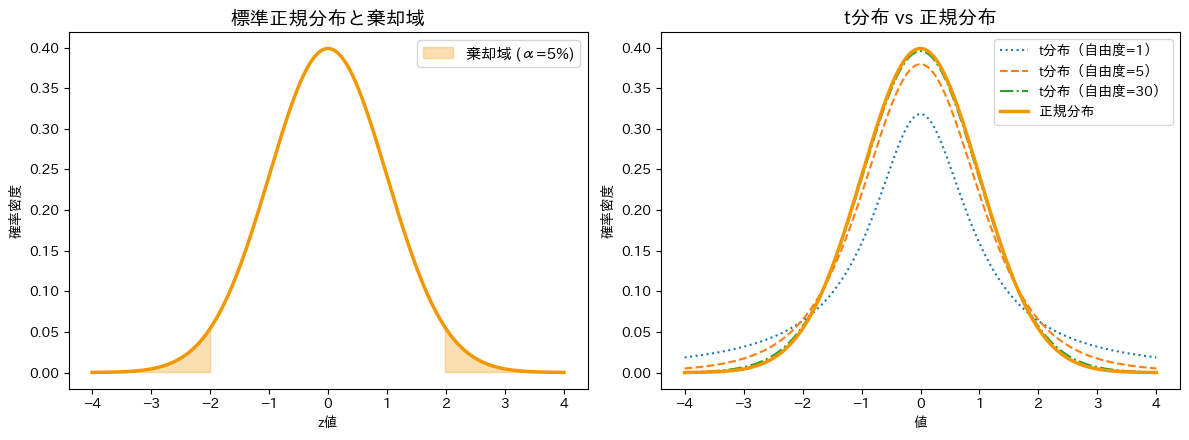

📌 自由度30になるとほぼ重なりますが、n=5〜10 の小サンプルでは
　 t分布の裾の厚さがp値に影響します。
　 → サンプルが少ないからこそ、あえてt分布を使う意味がある


In [4]:
# --- 正規分布の描画（棄却域付き）---
x = np.linspace(-4, 4, 200)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 左：標準正規分布と棄却域
ax = axes[0]
ax.plot(x, stats.norm.pdf(x), color=GU_ORANGE, linewidth=2.5)
ax.fill_between(x, stats.norm.pdf(x), where=(x < -1.96) | (x > 1.96),
                alpha=0.3, color=GU_ORANGE, label='棄却域 (α=5%)')
ax.set_title('標準正規分布と棄却域', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlabel('z値')
ax.set_ylabel('確率密度')

# 右：t分布と正規分布の比較
ax = axes[1]
for df_val, ls in zip([1, 5, 30], [':', '--', '-.']):
    ax.plot(x, stats.t.pdf(x, df_val), linestyle=ls, linewidth=1.5,
            label=f't分布（自由度={df_val}）')
ax.plot(x, stats.norm.pdf(x), color=GU_ORANGE, linewidth=2.5, label='正規分布')
ax.set_title('t分布 vs 正規分布', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlabel('値')
ax.set_ylabel('確率密度')

plt.tight_layout()
plt.show()

print("📌 自由度30になるとほぼ重なりますが、n=5〜10 の小サンプルでは")
print("　 t分布の裾の厚さがp値に影響します。")
print("　 → サンプルが少ないからこそ、あえてt分布を使う意味がある")


### 1-2. ライン A の製品重量データを確認

data.csv から「通常生産・ライン A」のデータを取り出して、分布を確認します。

ライン A の製品重量データ: 30 個（通常生産のみ）
  平均　　: 12.208 g
  標本分散 (n で割る)  : 0.0670
  不偏分散 (n-1で割る) : 0.0693



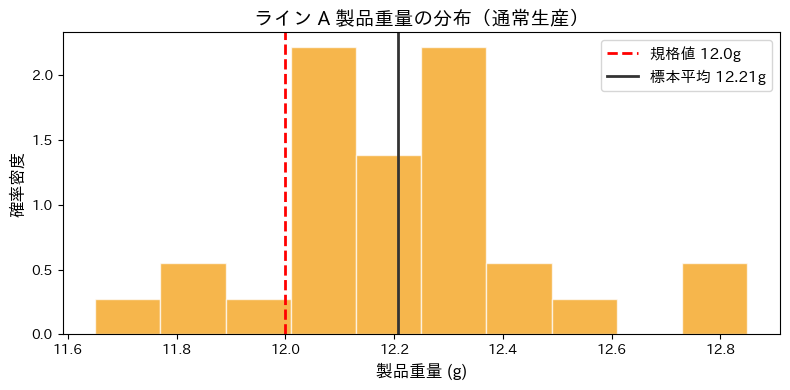

In [5]:
# --- ライン A の製品重量データを抽出（通常生産のみ） ---
# ⚠️ 重要: 計画実験もライン A ですが、ここでは通常生産のみを使用します
line_a = df[(df['種別'] == '通常生産') & (df['ライン'] == 'A')]
weights = line_a['製品重量']

print(f"ライン A の製品重量データ: {len(weights)} 個（通常生産のみ）")
print(f"  平均　　: {weights.mean():.3f} g")
print(f"  標本分散 (n で割る)  : {np.var(weights):.4f}")
print(f"  不偏分散 (n-1で割る) : {np.var(weights, ddof=1):.4f}")  # 🔑 ddof=1
print()

# ヒストグラムで分布を確認
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(weights, bins=10, color=GU_ORANGE, alpha=0.7, edgecolor='white', density=True)
ax.axvline(12.0, color='red', linewidth=2, linestyle='--', label='規格値 12.0g')
ax.axvline(weights.mean(), color=GU_BLACK, linewidth=2, label=f'標本平均 {weights.mean():.2f}g')
ax.set_xlabel('製品重量 (g)', fontsize=12)
ax.set_ylabel('確率密度', fontsize=12)
ax.set_title('ライン A 製品重量の分布（通常生産）', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 1-3. 1標本t検定：規格値 12.0g と差があるか？

🔑 **キーライン：**

- `popmean=12.0` ← 検定する規格値（ここを変えるとp値が変わる）
- `p_val < 0.05` ← 有意水準の判定

In [6]:
# --- 1標本t検定 ---
# 🔑 キーライン：popmean の値を変えてみてください
t_stat, p_val = stats.ttest_1samp(weights, popmean=11.5)

print("=" * 55)
print("　　1標本t検定の結果（ライン A 製品重量 vs 規格値）")
print("=" * 55)
print(f"  サンプル数　: {len(weights)}")
print(f"  標本平均　　: {weights.mean():.3f} g")
print(f"  不偏標準偏差: {weights.std(ddof=1):.3f} g")
print(f"  規格値　　　: 12.0 g")
print()
print(f"  t統計量: {t_stat:.3f}")
print(f"  p値　　: {p_val:.4f}")
print()

# 🔑 キーライン：有意水準の判定
if p_val < 0.05:
    print("  ✅ 判定: p < 0.05 → 有意差あり（規格値と異なる可能性）")
else:
    print("  ❌ 判定: p ≥ 0.05 → 有意差なし（規格通りと言える）")
print("=" * 55)
print()
print("💡 popmean=12.0 を 11.5 や 12.5 に変えて再実行してみてください。")


　　1標本t検定の結果（ライン A 製品重量 vs 規格値）
  サンプル数　: 30
  標本平均　　: 12.208 g
  不偏標準偏差: 0.263 g
  規格値　　　: 12.0 g

  t統計量: 14.728
  p値　　: 0.0000

  ✅ 判定: p < 0.05 → 有意差あり（規格値と異なる可能性）

💡 popmean=12.0 を 11.5 や 12.5 に変えて再実行してみてください。


### 📏 どちらの分布を使えばいい？─ 実務の判断目安

| サンプルサイズ | 実務上の判断 |
|:---|:---|
| n ≥ 100 程度 | 正規分布で近似しても大きな誤りにはなりません |
| **n = 10〜30 程度** | **t分布を使ってください（今日の検定はこちらが対象）** |
| n ≤ 5 程度 | t検定も不安定。実験の繰り返しを増やすことを優先 |

**迷ったらt分布** を選んでおけば間違いは少ないです。

---

---

# 🖥️ デモ ② ： L8型直交配列表と主効果の可視化

**（第3章 直交計画 ─ 14:15〜14:30）**

### ストーリー

> GUフーズでは収率向上のため、7つの要因（温度・湿度・圧力・時間・pH・触媒・攪拌速度）を
> **L8直交配列表**で計画的に実験しました。data.csv の「計画実験」8行がその結果です。
> どの要因が収率に最も影響するかを、主効果の棒グラフで確認します。

### このデモで確認すること

- data.csv から計画実験データを抽出
- 各要因を水準1/水準2に変換（低温=1, 高温=2 など）
- 主効果（水準別平均の差）を棒グラフで比較
- 効果量のランキング

### 2-1. 計画実験データの抽出> ⚠️ 表の「水準1」「水準2」は数値ではなく **ラベル**（ON/OFF）です。

In [8]:
# --- data.csv から計画実験データを抽出 ---
df_exp = df[df['種別'] == '計画実験'].copy().reset_index(drop=True)

print(f"📋 計画実験データ: {len(df_exp)} 行（L8直交配列表）")
print()
print(df_exp.to_string(index=False))


📋 計画実験データ: 8 行（L8直交配列表）

実験ID   種別 ライン   温度   湿度  圧力   時間  pH 触媒 攪拌速度   収率  製品重量
E001 計画実験   A 70.0 40.0 2.0 20.0 6.0  X    低 64.4 12.26
E002 計画実験   A 70.0 40.0 2.0 50.0 8.0  Y    高 71.4 12.69
E003 計画実験   A 70.0 70.0 4.0 20.0 6.0  Y    高 72.7 12.41
E004 計画実験   A 70.0 70.0 4.0 50.0 8.0  X    低 66.2 12.24
E005 計画実験   A 90.0 40.0 4.0 20.0 8.0  X    高 81.6 12.26
E006 計画実験   A 90.0 40.0 4.0 50.0 6.0  Y    低 82.2 12.44
E007 計画実験   A 90.0 70.0 2.0 20.0 8.0  Y    低 72.4 12.72
E008 計画実験   A 90.0 70.0 2.0 50.0 6.0  X    高 74.8 12.51


In [9]:
# --- 各要因を水準番号（1/2）に変換 ---
# 因子と水準の対応表
factor_map = {
    '温度':    {70.0: 1, 90.0: 2},
    '湿度':    {40.0: 1, 70.0: 2},
    '圧力':    {2.0: 1, 4.0: 2},
    '時間':    {20.0: 1, 50.0: 2},
    'pH':      {6.0: 1, 8.0: 2},
    '触媒':    {'X': 1, 'Y': 2},
    '攪拌速度': {'低': 1, '高': 2},
}

# 水準ラベルの対応表（表示用）
level_labels = {
    '温度':    {1: '低温(70℃)', 2: '高温(90℃)'},
    '湿度':    {1: '低湿(40%)', 2: '高湿(70%)'},
    '圧力':    {1: '低圧(2atm)', 2: '高圧(4atm)'},
    '時間':    {1: '短(20min)', 2: '長(50min)'},
    'pH':      {1: '低(6.0)', 2: '高(8.0)'},
    '触媒':    {1: 'X', 2: 'Y'},
    '攪拌速度': {1: '低速', 2: '高速'},
}

factor_names = list(factor_map.keys())
df_L8 = pd.DataFrame()

for fname in factor_names:
    df_L8[fname] = df_exp[fname].map(factor_map[fname])

df_L8['収率'] = df_exp['収率'].values

print("📋 L8直交配列表（水準番号に変換済み）:")
print()
print(df_L8.to_string(index=False))
print()
print("💡 「1」= 水準1、「2」= 水準2（ラベルであり、計算に使う数値ではありません）")


📋 L8直交配列表（水準番号に変換済み）:

 温度  湿度  圧力  時間  pH  触媒  攪拌速度   収率
  1   1   1   1   1   1     1 64.4
  1   1   1   2   2   2     2 71.4
  1   2   2   1   1   2     2 72.7
  1   2   2   2   2   1     1 66.2
  2   1   2   1   2   1     2 81.6
  2   1   2   2   1   2     1 82.2
  2   2   1   1   2   2     1 72.4
  2   2   1   2   1   1     2 74.8

💡 「1」= 水準1、「2」= 水準2（ラベルであり、計算に使う数値ではありません）


### 2-2. 各要因の主効果の可視化

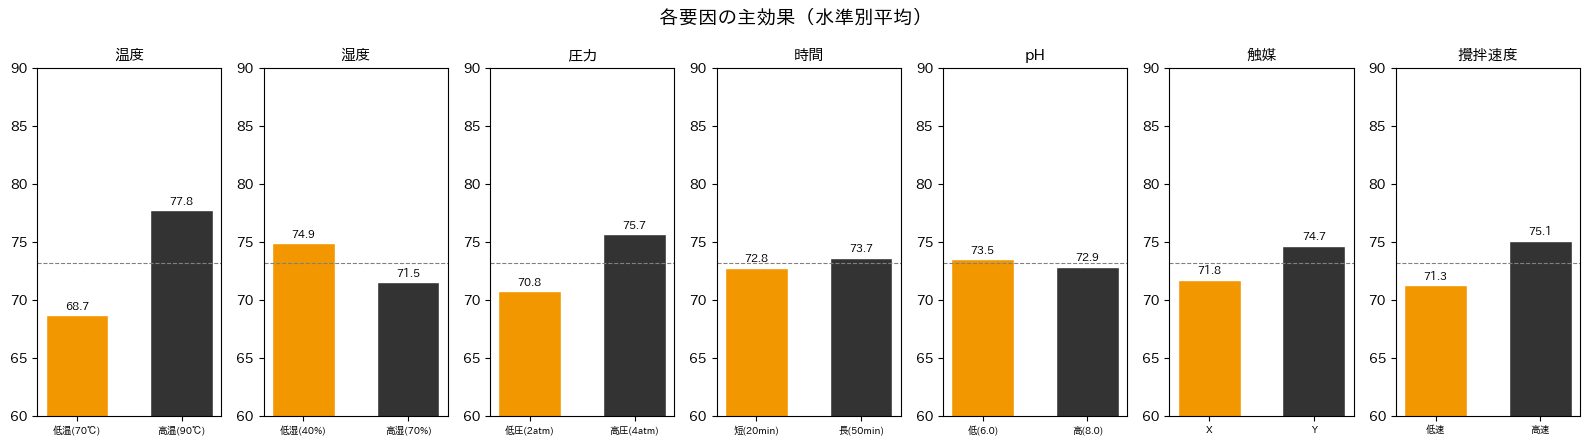

In [10]:
# --- 主効果の計算と可視化 ---
fig, axes = plt.subplots(1, 7, figsize=(16, 4.5))
fig.suptitle('各要因の主効果（水準別平均）', fontsize=14, fontweight='bold')

for ax, col in zip(axes, factor_names):
    means = df_L8.groupby(col)['収率'].mean()
    labels_disp = [level_labels[col][1], level_labels[col][2]]
    bars = ax.bar(labels_disp, means.values, color=[GU_ORANGE, GU_BLACK],
                  width=0.6, edgecolor='white')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylim(60, 90)
    ax.axhline(df_L8['収率'].mean(), color='gray', linestyle='--', linewidth=0.8)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8)
    ax.tick_params(axis='x', labelsize=7)

plt.tight_layout()
plt.show()


In [11]:
# --- 効果量のランキング ---
effects = {}
for col in factor_names:
    m1 = df_L8[df_L8[col]==1]['収率'].mean()
    m2 = df_L8[df_L8[col]==2]['収率'].mean()
    effects[col] = round(m2 - m1, 1)

print("📊 主効果の大きさランキング（水準2 − 水準1）:")
print()
for rank, (k, v) in enumerate(sorted(effects.items(), key=lambda x: abs(x[1]), reverse=True), 1):
    bar = '█' * int(abs(v))
    sign = '↑' if v > 0 else '↓'
    print(f"  {rank}位  {k:6s}: {v:+5.1f}  {sign} {bar}")

print()
print("💡 絶対値が大きいほど収率への影響が大きい要因です。")


📊 主効果の大きさランキング（水準2 − 水準1）:

  1位  温度    :  +9.1  ↑ █████████
  2位  圧力    :  +4.9  ↑ ████
  3位  攪拌速度  :  +3.8  ↑ ███
  4位  湿度    :  -3.4  ↓ ███
  5位  触媒    :  +2.9  ↑ ██
  6位  時間    :  +0.9  ↑ 
  7位  pH    :  -0.6  ↓ 

💡 絶対値が大きいほど収率への影響が大きい要因です。


---

---

# 🖥️ デモ ③ ： 分散分析と多重比較・交互作用プロット

**（第4章 分散分析の実践 ─ 15:55〜16:10）**

### ストーリー

> GUフーズには3つの製造ライン（A・B・C）があります。
> data.csv の「通常生産」データを使って、**ライン間で収率に差があるか** を検定します。
> さらに、温度設定（高温/低温）とラインの間に **交互作用** がないかも確認します。

### このデモで確認すること

- 一元配置分散分析：3ライン間の収率の差を検定
- Tukey-Kramer多重比較：どのライン間に差があるか
- 交互作用プロット：「なし」と「あり」の対比

### 3-1. ライン別の収率を確認

📋 通常生産データ: 90 行

【ライン別の収率】
  ラインA: 平均=30.2, 標準偏差=7.6, n=30
  ラインB: 平均=44.2, 標準偏差=8.2, n=30
  ラインC: 平均=22.1, 標準偏差=8.1, n=30


/var/folders/8b/c9rc44k11ddfj4bll7v1y5lm0000gn/T/ipykernel_2092/1994477515.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_line, labels=['ライン A', 'ライン B', 'ライン C'],


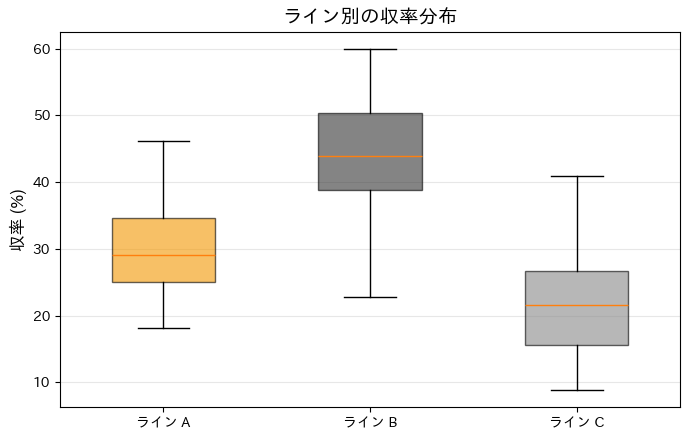

In [12]:
# --- 通常生産データを抽出 ---
df_prod = df[df['種別'] == '通常生産'].copy()

print(f"📋 通常生産データ: {len(df_prod)} 行")
print()
print("【ライン別の収率】")
for line in ['A', 'B', 'C']:
    y = df_prod[df_prod['ライン']==line]['収率']
    print(f"  ライン{line}: 平均={y.mean():.1f}, 標準偏差={y.std():.1f}, n={len(y)}")

# 箱ひげ図
fig, ax = plt.subplots(figsize=(7, 4.5))
data_by_line = [df_prod[df_prod['ライン']==l]['収率'].values for l in ['A','B','C']]
bp = ax.boxplot(data_by_line, labels=['ライン A', 'ライン B', 'ライン C'],
                patch_artist=True, widths=0.5)
colors_box = [GU_ORANGE, GU_BLACK, '#888888']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('収率 (%)', fontsize=12)
ax.set_title('ライン別の収率分布', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### 3-2. 一元配置分散分析（ANOVA）

In [13]:
# --- 一元配置分散分析 ---
group_A = df_prod[df_prod['ライン']=='A']['収率'].values
group_B = df_prod[df_prod['ライン']=='B']['収率'].values
group_C = df_prod[df_prod['ライン']=='C']['収率'].values

# 🔑 キーライン：グループをカンマで増やすだけでOK
f_stat, p_val = stats.f_oneway(group_A, group_B, group_C)

print("=" * 55)
print("　　一元配置分散分析（ANOVA）の結果")
print("=" * 55)
print(f"  ライン A 平均: {group_A.mean():.1f}　(n={len(group_A)})")
print(f"  ライン B 平均: {group_B.mean():.1f}　(n={len(group_B)})")
print(f"  ライン C 平均: {group_C.mean():.1f}　(n={len(group_C)})")
print()
print(f"  F値: {f_stat:.3f}")
print(f"  p値: {p_val:.6f}")
print()
if p_val < 0.05:
    print("  ✅ 判定: p < 0.05 → 有意差あり（どこかのライン間に差がある）")
    print("  　 → 次のステップ：Tukey多重比較でどのライン間か調べる")
else:
    print("  ❌ 判定: p ≥ 0.05 → 有意差なし")
print("=" * 55)


　　一元配置分散分析（ANOVA）の結果
  ライン A 平均: 30.2　(n=30)
  ライン B 平均: 44.2　(n=30)
  ライン C 平均: 22.1　(n=30)

  F値: 58.427
  p値: 0.000000

  ✅ 判定: p < 0.05 → 有意差あり（どこかのライン間に差がある）
  　 → 次のステップ：Tukey多重比較でどのライン間か調べる


### 3-3. Tukey-Kramer 多重比較

★ **基本推奨：迷ったら Tukey-Kramer**

In [ ]:
# --- Tukey-Kramer 多重比較 ---
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 🔑 キーライン：alpha の値を変えると判定の厳しさが変わる
result = pairwise_tukeyhsd(df_prod['収率'], df_prod['ライン'], alpha=0.05)

print("📊 Tukey-Kramer 多重比較の結果")
print()
print(result)
print()
print("💡 reject=True の行 → そのライン間に有意差あり")


### 3-4. 交互作用プロット ─ 平行 vs 交差

> **ここが今日の山場です！**

data.csv のデータを「温度が中央値より高い/低い」で2群に分け、ライン × 温度区分 の交互作用を確認します。

In [ ]:
# --- 交互作用プロット（実データから）---
# 温度を中央値で「低温」「高温」に分ける
temp_median = df_prod['温度'].median()
df_prod['温度区分'] = df_prod['温度'].apply(lambda x: '高温' if x >= temp_median else '低温')

# ライン×温度区分 の平均収率を計算
interaction = df_prod.groupby(['ライン', '温度区分'])['収率'].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# 左：実データの交互作用プロット
ax = axes[0]
for line, (style, color, marker) in zip(['A','B','C'],
    [('-', GU_ORANGE, 'o'), ('--', GU_BLACK, 's'), (':', '#888888', '^')]):
    vals = [interaction.loc[line, '低温'], interaction.loc[line, '高温']]
    ax.plot(['低温', '高温'], vals, marker+style, color=color, linewidth=2.5,
            markersize=8, label=f'ライン {line}')
ax.set_title('実データの交互作用プロット\n（ライン × 温度区分）',
             fontsize=12, fontweight='bold')
ax.set_ylabel('収率 (%)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# 右：交互作用「あり」のパターン例（比較用）
ax = axes[1]
ax.plot(['低温', '高温'], [30, 48], 'o-', color=GU_ORANGE, linewidth=2.5,
        markersize=8, label='ライン A（高温で急増）')
ax.plot(['低温', '高温'], [45, 28], 's--', color=GU_BLACK, linewidth=2.5,
        markersize=8, label='ライン B（高温で急減）')
ax.plot(['低温', '高温'], [22, 24], '^:', color='#888888', linewidth=2.5,
        markersize=8, label='ライン C（ほぼ不変）')
ax.set_title('交互作用「あり」のパターン例\n（折れ線が交差 → 効果が逆転！）',
             fontsize=12, color='darkred', fontweight='bold')
ax.set_ylabel('収率 (%)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.annotate('← 交差！', xy=(0.5, 0.5), xycoords='axes fraction',
            fontsize=14, color='darkred', ha='center', fontweight='bold')

plt.suptitle('交互作用プロットの見方：平行（左）vs 交差（右）',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("📌 左：実データ。折れ線がほぼ平行なら交互作用は弱い")
print("📌 右：参考パターン。折れ線が交差 → 交互作用あり（主効果だけ見ると危険！）")


### 3-5. 二元配置分散分析

In [ ]:
# --- 二元配置分散分析（ライン × 温度区分）---
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

model_2way = smf.ols('収率 ~ C(ライン) + C(温度区分) + C(ライン):C(温度区分)',
                      data=df_prod).fit()

print("📊 二元配置分散分析表（ライン × 温度区分）")
print()
anova_table = anova_lm(model_2way, typ=2).round(4)
print(anova_table)
print()
print("─" * 60)
print("👉 注目するのは p値（PR(>F)）の列だけ！")
print("　 C(ライン)           → ライン間の主効果")
print("　 C(温度区分)         → 温度区分の主効果")
print("　 C(ライン):C(温度区分) → 交互作用")
print("　 p値が 0.05 未満なら有意")
print("─" * 60)


---

---

# 🖥️ デモ ④ ： 重回帰分析の実行と結果の解釈

**（第5章 多変量解析 ─ 16:40〜16:50）**

### ストーリー

> GUフーズの通常生産データ（90行）を使って、
> **温度・湿度・圧力から収率を予測するモデル** を構築します。
> どの要因が収率に最も影響しているか、データから明らかにします。

### このデモで確認すること

- 重回帰分析の実行と `model.summary()` の読み方
- coef（偏回帰係数）と P>|t|（p値）の2列だけ見ればOK
- R²（決定係数）：モデルの説明力
- VIF で多重共線性をチェック
- 主成分分析（概要のみ）

> ⚠️ **注意：** 今日のデモデータは理解しやすいように作られたサンプルデータです。
> 実務では **データ前処理が全作業の7〜8割** を占めます。

### 4-1. 重回帰分析の実行

In [ ]:
# --- 重回帰分析（data.csv の通常生産データから）---
import statsmodels.api as sm

df_reg = df[df['種別'] == '通常生産'].copy()

# 説明変数: 温度, 湿度, 圧力  →  目的変数: 収率
X = sm.add_constant(df_reg[['温度', '湿度', '圧力']])
y = df_reg['収率']

model_reg = sm.OLS(y, X).fit()

print("📊 重回帰分析の結果")
print()
print(model_reg.summary())
print()
print("─" * 60)
print("👉 注目するのはこの2列だけ！")
print("　 coef    : 偏回帰係数（+なら正の影響、−なら負の影響）")
print("　 P>|t|   : p値（0.05未満なら「意味のある影響がある」変数）")
print()
print(f"📏 R² = {model_reg.rsquared:.3f}")
print(f"　 → モデルがデータ全変動の {model_reg.rsquared*100:.1f}% を説明")
print("─" * 60)


### 4-2. 偏回帰係数の可視化

In [ ]:
# --- 偏回帰係数の可視化 ---
coefs = model_reg.params[1:]  # 切片を除く
colors = [GU_ORANGE if c > 0 else GU_BLACK for c in coefs]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(coefs.index, coefs.values, color=colors, width=0.5,
              edgecolor='white', linewidth=1)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('偏回帰係数（各要因の独立した影響）', fontsize=14, fontweight='bold')
ax.set_ylabel('係数', fontsize=12)

for bar, val in zip(bars, coefs.values):
    y_pos = val + 0.03 if val >= 0 else val - 0.05
    ax.text(bar.get_x() + bar.get_width()/2, y_pos,
            f'{val:.3f}', ha='center', va='bottom' if val >= 0 else 'top',
            fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("📌 オレンジ = 正の影響（増やすと収率が上がる）")
print("📌 黒　　　 = 負の影響（増やすと収率が下がる）")


### 4-3. 多重共線性チェック（VIF）

> **VIF > 10 なら問題あり** の目安

In [ ]:
# --- 多重共線性チェック（VIF）---
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['変数'] = ['温度', '湿度', '圧力']
vif_data['VIF'] = [
    variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])
]

print("📊 VIF（分散拡大係数）")
print()
print(vif_data.to_string(index=False))
print()
print("─" * 50)
print("  VIF < 5　 → 問題なし ✅")
print("  VIF 5〜10 → 要注意 ⚠️")
print("  VIF > 10  → 多重共線性あり 🚨")
print("─" * 50)


### 4-4. 主成分分析（概要確認のみ）

In [ ]:
# --- 主成分分析 ---
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_reg[['温度', '湿度', '圧力']])
pca = PCA()
pca.fit(X_scaled)

print("📊 主成分分析の結果")
print(f"  各主成分の寄与率　: {pca.explained_variance_ratio_.round(3)}")
print(f"  累積寄与率　　　　: {pca.explained_variance_ratio_.cumsum().round(3)}")
print()

fig, ax = plt.subplots(figsize=(6, 4))
components = [f'第{i+1}主成分' for i in range(len(pca.explained_variance_ratio_))]
ax.bar(components, pca.explained_variance_ratio_ * 100,
       color=GU_ORANGE, width=0.5, edgecolor='white')
ax.plot(components, pca.explained_variance_ratio_.cumsum() * 100,
        'o-', color=GU_BLACK, linewidth=2, markersize=8, label='累積寄与率')
ax.set_ylabel('寄与率 (%)', fontsize=12)
ax.set_title('主成分分析：寄与率', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 110)
plt.tight_layout()
plt.show()


### 4-5. スコアプロット ─ 外れ値の可視化

> PC1・PC2 の2次元空間にサンプルをプロットします。  
> **中心から大きく離れた点**が外れ値の候補です。

In [ ]:
# --- スコアプロット（外れ値の可視化）---
# 🔑 キーライン：pca.transform() でスコア（主成分得点）を計算
scores = pca.transform(X_scaled)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(scores[:, 0], scores[:, 1],
           color=GU_ORANGE, edgecolors=GU_BLACK, linewidths=0.5,
           s=60, alpha=0.8)

# サンプル番号をラベル表示
for i, (x, y) in enumerate(zip(scores[:, 0], scores[:, 1])):
    ax.annotate(str(df_reg.index[i]), (x, y),
                textcoords='offset points', xytext=(5, 3), fontsize=7)

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title('PCA スコアプロット（外れ値確認）', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 中心（0, 0）から大きく離れた点が外れ値の候補です。')
print('   該当サンプルは df_reg.iloc[番号] で内容を確認できます。')

---

---

## 📝 まとめ

### 今日のデモの全体像（data.csv 1つで一気通貫）

| デモ | 使ったデータ | 分析手法 | キーポイント |
|:---|:---|:---|:---|
| ① | 通常生産・ライン A の製品重量 | 1標本t検定 | `popmean` で規格値を指定、`p < 0.05` で判定 |
| ② | 計画実験の8行（L8直交表） | 主効果分析 | 水準別平均の差で影響度をランキング |
| ③ | 通常生産のライン A/B/C | ANOVA → Tukey | `f_oneway` → `pairwise_tukeyhsd` → 交互作用プロット |
| ④ | 通常生産の温度・湿度・圧力 | 重回帰分析 | `coef` と `P>|t|` の2列、VIF でマルチコチェック |

### ストーリーの流れ

1. **品質検査**（デモ①）：製品重量が規格を満たしているか → t検定
2. **要因探索**（デモ②）：どの要因が収率に影響するか → 直交表で効率的に実験
3. **ライン比較**（デモ③）：どのラインの収率が高いか → 分散分析
4. **予測モデル**（デモ④）：条件から収率を予測できるか → 重回帰分析

### 実務への注意

- 今日のデータは **綺麗なサンプルデータ** です
- 実務では **データ前処理が全作業の7〜8割** を占めます
- 分析前に必ず **箱ひげ図** と **ヒストグラム** で分布を確認してください

---

**講師:** 鈴木 優（岐阜大学 工学部 教授）  
**お問い合わせ:** suzuki.yu.r4@f.gifu-u.ac.jp